In [83]:
import numpy as np
import open3d
from matplotlib import pyplot as plt

In [84]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
from pycamcal.primitives.rotation import Rotation3D as R3D

## Prepare Scene

In [97]:
from pycamcal.simulation.cornell_box import create_cornell_box
from pycamcal.simulation.checkerboard import create_checkerboard_mesh
from pycamcal.simulation.materials import *
from pycamcal.simulation.mesh_helpers import paint_uniform_material, create_rectangle_mesh

import random

# create basic environment for some nice visual context
cornell_box = create_cornell_box(width=6, height=5)

# create calibration target
checkerboard = create_checkerboard_mesh(num_rows=7, num_cols=10, square_size=0.25)
checkerboard.translate(-checkerboard.get_center())
checkerboard.translate([0, 1.9, 1])
checkerboard.rotate(R3D.from_euler("x", [90], degrees=True).as_matrix())

# create more visual interest
balls = []
for _ in range(1):
    ball = open3d.geometry.TriangleMesh.create_sphere(radius=0.5, resolution=100)
    paint_uniform_material(ball, MAT_MIRROR)
    # ball.translate(np.random.normal(loc=(0, 0, 0), scale=0.2))
    ball.translate([0, 0, 1])
    balls.append(ball)

# create a mirror on the right wall
mirror = create_rectangle_mesh(width=3, length=2)
paint_uniform_material(mirror, MAT_MIRROR)
mirror.rotate(R3D.from_euler("xy", [90, 90], degrees=True).as_matrix())
mirror.translate([2.9, 0, 2])

scene = [*cornell_box.values(), checkerboard, *balls, mirror]
print(scene)

[TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 8 points and 2 triangles., TriangleMesh with 280 points and 140 triangles., TriangleMesh with 19802 points and 39600 triangles., TriangleMesh with 4 points and 2 triangles.]


In [98]:
# preview scene geometry
if False:
    open3d.visualization.draw_geometries(scene, mesh_show_back_face=True)

## Prepare Camera

In [99]:
from pycamcal.camera_model import CameraModel
from pycamcal.camera_model import RadialTangentialDistortion

distortion = RadialTangentialDistortion(
    k1=-0.25,
    k2=+0.05,
    k3=0.0,
    p1=0.0,
    p2=0.0
)

camera = CameraModel.from_fov(
    res_xy = (1200, 1000),
    fov_xy = (72, 60),
    # distortion = distortion
    distortion = None
)

print(camera)

if not distortion.is_valid_over_entire_fov(camera.get_fov(degrees=False)):
    print("WARNING: Distortion model is not valid over entire FOV! Certain regions are potentially unreachable and inversion behavior may be undefined.")## Prepare Camera

{'res_xy': [1200, 1000],
 'fx': Array(825.82916, dtype=float32),
 'fy': Array(866.0254, dtype=float32),
 'cx': 600.0,
 'cy': 500.0,
 'distortion': None}


## Render

Bounce depth: 0 | Rays in flight: 4800000
Num mirror hits:      154126
Num mirror hits:      551752

Bounce depth: 1 | Rays in flight: 705878
Num mirror hits:      6585

Bounce depth: 2 | Rays in flight: 6585
Num mirror hits:      141

Bounce depth: 3 | Rays in flight: 141

(1000, 1200, 3)


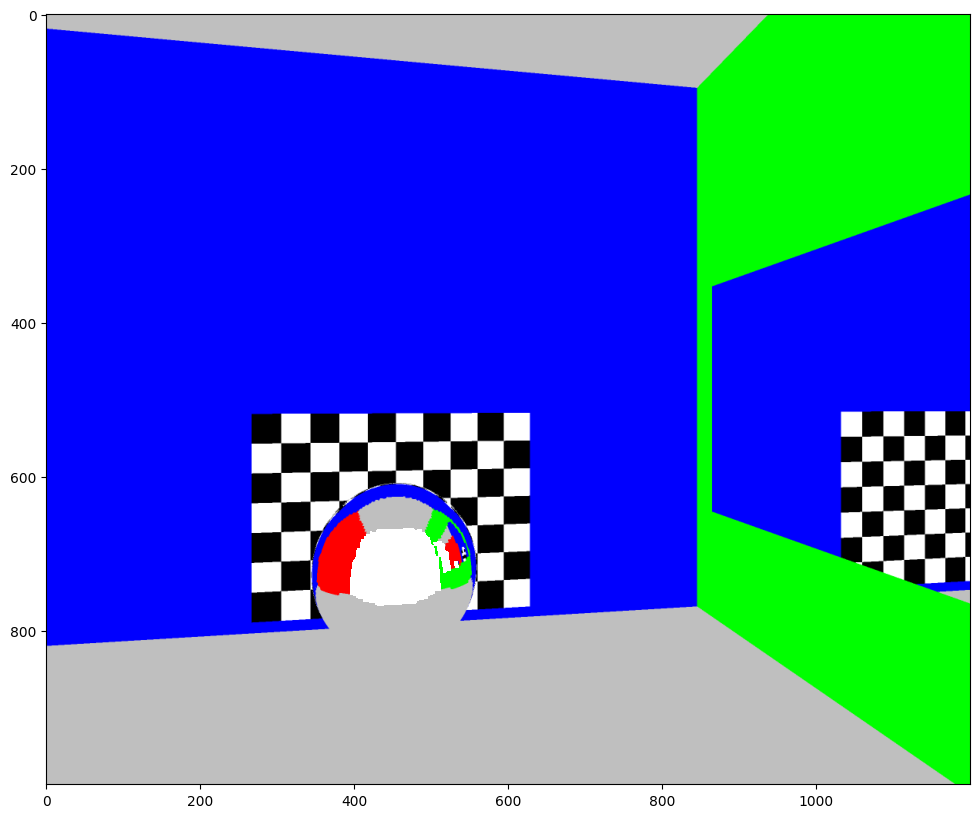

In [103]:
from pycamcal.primitives.pose import Pose3D
from pycamcal.simulation.raycasting import simulate_capture

camera_pose = Pose3D(
    np.array([0, -4.0, 2.0]),
    R3D.from_euler("xy", [-90, 10], degrees=True)
)

image = simulate_capture(scene, camera, camera_pose, rays_per_pixel=4)
print(image.shape)

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(image)